In [1]:
import os

folder_name = "Arabiansea_Profiles"
folder_path = rf"C:\INCOIS\ARGO\DATA\{folder_name}"

os.makedirs(folder_path, exist_ok=True)

print("Folder created:", folder_path)

Folder created: C:\INCOIS\ARGO\DATA\Arabiansea_Profiles


In [1]:
import pandas as pd

file_path = r"C:\INCOiS\ARGO\DATA\Raw_Data\ar_index_global_prof.txt"

df = pd.read_csv(file_path, comment="#")

print(df.head())

                                file          date  latitude  longitude ocean  \
0  aoml/13857/profiles/D13857_001.nc  1.997073e+13     0.267    -16.032     A   
1  aoml/13857/profiles/D13857_002.nc  1.997081e+13     0.072    -17.659     A   
2  aoml/13857/profiles/D13857_003.nc  1.997082e+13     0.543    -19.622     A   
3  aoml/13857/profiles/D13857_004.nc  1.997083e+13     1.256    -20.521     A   
4  aoml/13857/profiles/D13857_005.nc  1.997091e+13     0.720    -20.768     A   

   profiler_type institution     date_update  
0            845          AO  20260220143529  
1            845          AO  20260220143529  
2            845          AO  20260220143530  
3            845          AO  20260220143530  
4            845          AO  20260220143530  


In [2]:
print(df.columns)


Index(['file', 'date', 'latitude', 'longitude', 'ocean', 'profiler_type',
       'institution', 'date_update'],
      dtype='object')


In [5]:
date=df['date'].values
print(date)
longitude = df['longitude'].values
print(longitude)
latitude=df['latitude'].values
print(latitude)
institution=df['institution'].values
print(institution)
ocean=df['ocean'].values
print(ocean)

[1.99707292e+13 1.99708092e+13 1.99708202e+13 ... 2.01305210e+13
 2.01305310e+13 2.01306100e+13]
[-16.032 -17.659 -19.622 ... 138.677 138.465 138.09 ]
[ 0.267  0.072  0.543 ... 27.692 27.895 27.931]
['AO' 'AO' 'AO' ... 'NM' 'NM' 'NM']
['A' 'A' 'A' ... 'P' 'P' 'P']


In [7]:

ocean_df=df[df['ocean']=='I']
print(ocean_df.head())
print(ocean_df['ocean'])

                                       file          date  latitude  \
1695  aoml/1900042/profiles/D1900042_001.nc  2.002113e+13   -45.966   
1696  aoml/1900042/profiles/D1900042_002.nc  2.002121e+13   -45.755   
1697  aoml/1900042/profiles/D1900042_003.nc  2.002122e+13   -45.618   
1698  aoml/1900042/profiles/D1900042_004.nc  2.002123e+13   -45.588   
1699  aoml/1900042/profiles/D1900042_005.nc  2.003011e+13   -45.637   

      longitude ocean  profiler_type institution     date_update  
1695     51.947     I            846          AO  20150227132442  
1696     51.582     I            846          AO  20150227132442  
1697     51.514     I            846          AO  20150227132442  
1698     51.548     I            846          AO  20150227132442  
1699     51.507     I            846          AO  20150227132443  
1695       I
1696       I
1697       I
1698       I
1699       I
          ..
3352267    I
3352268    I
3352269    I
3352270    I
3352271    I
Name: ocean, Length: 641018,

enter size of grid 5


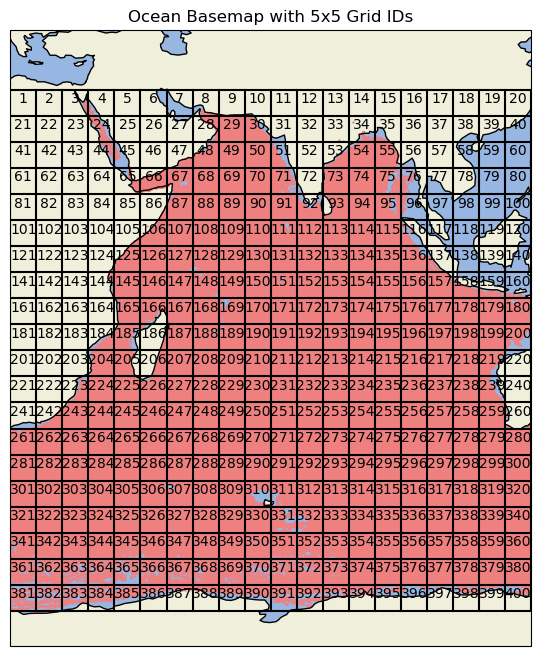

In [11]:
import matplotlib.pyplot as plt
import numpy as np
!pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Map boundaries
lon_min, lon_max = 20, 120
lat_min, lat_max = -70,30

g_size=int(input("enter size of grid"))
rows=(lat_max-lat_min)/g_size
cols=(lon_max-lon_min)/g_size
rows=int(rows)
cols=int(cols)

# Create grid lines
lon_lines = np.linspace(lon_min, lon_max, cols + 1)
lat_lines = np.linspace(lat_min, lat_max, rows + 1)

# Create figure
fig = plt.figure(figsize=(10,8))

# Create map projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Add ocean and land
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)

# Add coastlines
ax.coastlines()

# Draw vertical grid lines
for lon in lon_lines:
    ax.plot(
        [lon, lon],
        [lat_min, lat_max],
        color='black',
        transform=ccrs.PlateCarree()
    )

# Draw horizontal grid lines
for lat in lat_lines:
    ax.plot(
        [lon_min, lon_max],
        [lat, lat],
        color='black',
        transform=ccrs.PlateCarree()
    )

# Add grid IDs
grid_id = 1

for i in reversed(range(rows)):
    for j in range(cols):

        # Grid center
        x_center = (lon_lines[j] + lon_lines[j+1]) / 2
        y_center = (lat_lines[i] + lat_lines[i+1]) / 2

        # Add text label
        ax.text(
            x_center,
            y_center,
            f"{grid_id}",
            transform=ccrs.PlateCarree(),
            ha='center',
            fontsize=10,
            color='black'
        )

        grid_id += 1
ax.scatter(
    ocean_df['longitude'],
    ocean_df['latitude'],
    s=0.5,

    color='lightcoral',
    transform=ccrs.PlateCarree()   # ✅ Correct
)

# Add title
plt.title("Ocean Basemap with 5x5 Grid IDs")

# Show map
plt.show()

In [13]:
import numpy as np
ocean_df = ocean_df.copy()
# Grid size
g_size = 5

ocean_df['grid_col'] = (
    ((ocean_df['longitude'] - lon_min) // g_size).astype(int)

)

ocean_df['grid_row'] = (
    ((lat_max - ocean_df['latitude']) // g_size).astype(int)

)
ocean_df['grid_id'] = (
    ocean_df['grid_row'] * cols
    + ocean_df['grid_col']
    + 1)

grid7 = ocean_df[ocean_df['grid_id'] == 7]

print(grid7)
grid_profiles = dict(tuple(ocean_df.groupby('grid_id')))
profile_count = ocean_df.groupby('grid_id').size()

print(profile_count)
grid7 = ocean_df[ocean_df['grid_id'] == 7]

print(profile_count.head(40))

Empty DataFrame
Columns: [file, date, latitude, longitude, ocean, profiler_type, institution, date_update, grid_col, grid_row, grid_id]
Index: []
grid_id
3      135
4       99
8      684
9       44
24     796
      ... 
401    111
402     23
403     12
404     29
405    185
Length: 325, dtype: int64
grid_id
3      135
4       99
8      684
9       44
24     796
28    4420
29    9610
30    3635
33       2
34     160
35     108
44     436
45     251
47     786
48    3184
49    6243
50    8989
51    1409
53     893
54    6697
55    4399
56       3
65     829
66    2987
67    2206
68    2910
69    5679
70    6858
71    1759
72      43
73    4125
74    8216
75    2999
76     101
86     171
87    2157
88    2187
89    3342
90    4410
91    2369
dtype: int64


##### grid4= ocean_df[ocean_df['grid_id'] == 115
]

print(len(grid4))

In [15]:
bob_df = ocean_df[
    (ocean_df["latitude"] >= 5) &
    (ocean_df["latitude"] <= 25) &
    (ocean_df["longitude"] >= 80) &
    (ocean_df["longitude"] <= 100)
]


In [17]:
print("Profiles in Bay of Bengal:", len(bob_df))

Profiles in Bay of Bengal: 36564


In [19]:
print(bob_df.columns.tolist())


['file', 'date', 'latitude', 'longitude', 'ocean', 'profiler_type', 'institution', 'date_update', 'grid_col', 'grid_row', 'grid_id']


In [ ]:
import os
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

# Bay of Bengal limits
LAT_MIN = 5
LAT_MAX = 25
LON_MIN = 80
LON_MAX = 100

base_folder = r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles\bob_coordinates"
os.makedirs(base_folder, exist_ok=True)

# Filter only Bay of Bengal profiles
bob_df = ocean_df[
    (ocean_df["latitude"] >= LAT_MIN) &
    (ocean_df["latitude"] <= LAT_MAX) &
    (ocean_df["longitude"] >= LON_MIN) &
    (ocean_df["longitude"] <= LON_MAX)
]

# Existing downloaded files
existing_files = set(
    f for f in os.listdir(base_folder)
    if f.endswith(".nc")
)

# Keep only files not already downloaded
new_profiles = bob_df[
    ~bob_df["file"].apply(
        lambda x: os.path.basename(x) in existing_files
    )
]

print("Total Bay of Bengal profiles:", len(bob_df))
print("Already downloaded:", len(existing_files))
print("New profiles to download:", len(new_profiles))


def download_file(file_path):

    filename = os.path.basename(file_path)

    url = "https://data-argo.ifremer.fr/dac/" + file_path

    save_path = os.path.join(base_folder, filename)

    try:
        r = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=120
        )

        if r.status_code == 200:

            with open(save_path, "wb") as f:
                f.write(r.content)

            return filename

    except Exception as e:
        print(f"Error downloading {filename}: {e}")


with ThreadPoolExecutor(max_workers=8) as executor:

    futures = [
        executor.submit(download_file, fp)
        for fp in new_profiles["file"]
    ]

    completed = 0

    for future in as_completed(futures):

        completed += 1

        if completed % 100 == 0:
            print(
                f"Progress: "
                f"{completed}/{len(new_profiles)}"
            )

print("Download complete.")

In [ ]:
import os
import requests
save_folder = r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles\bob_coordinates"
os.makedirs(save_folder, exist_ok=True)
failed_files = [
    "D2902280_024.nc",
    "D2902280_025.nc",
    "D2902280_026.nc"
]
dac_subfolder = "incois/2902280/profiles/" 

for filename in failed_files:
    save_path = os.path.join(save_folder, filename)
    
    # Full URL path generation
    # Note: If your dataframe 'file' column contains the full 'dac/...' path, 
    # replace `dac_subfolder + filename` directly with that path string.
    url = f"https://data-argo.ifremer.fr/dac/{dac_subfolder}{filename}"
    
    print(f"Downloading {filename}...")
    try:
        r = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=180
        )
        
        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)
            print(f"Success: {filename} saved.")
        else:
            print(f"Failed: Server responded with status code {r.status_code}")
            
    except Exception as e:
        print(f"Error downloading {filename}: {e}")

print("Individual file download process complete.")

In [ ]:
bob_grid_ids = sorted(bob_df["grid_id"].unique())
print("Number of Bay of Bengal grids:", len(bob_grid_ids))
print(bob_grid_ids)

In [ ]:
import xarray as xr

ds = xr.open_dataset(
    r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles\bob_coordinates\grid_35\D2900226_115.nc",
    decode_times=False
)

print(list(ds.variables))
temp = ds.variables['TEMP'][:]
sal = ds.variables['PSAL'][:]


print("Temperature :", ds['TEMP'].values)
print("Salinity:", ds['PSAL'].values)
print(temp.shape)
print(sal.shape)

In [ ]:
from netCDF4 import Dataset
import numpy as np
import pandas as pd
import os

# Folder containing all Bay of Bengal grid folders
base_folder = r"C:\INCOiS\ARGO\DATA\Arabiansea_Profiles\as_coordinates"

# Bay of Bengal grid IDs from your dataframe
bob_grids = sorted(as_df["grid_id"].unique())

results = []

total_grids = len(bob_grids)

for grid_num, grid_id in enumerate(bob_grids, start=1):

    print(f"\nProcessing Grid {grid_id} ({grid_num}/{total_grids})")

    grid_folder = os.path.join(base_folder, f"grid_{grid_id}")

    if not os.path.exists(grid_folder):
        print(f"Grid {grid_id} folder not found")
        continue

    files = [f for f in os.listdir(grid_folder) if f.endswith(".nc")]

    if len(files) == 0:
        print(f"Grid {grid_id} contains no .nc files")
        continue

    # Statistics
    max_temp = -np.inf
    min_temp = np.inf
    sum_temp = 0
    count_temp = 0

    max_sal = -np.inf
    min_sal = np.inf
    sum_sal = 0
    count_sal = 0

    max_depth = -np.inf
    min_depth = np.inf

    total_files = len(files)

    for file_num, file in enumerate(files, start=1):

        path = os.path.join(grid_folder, file)

        try:
            ds = Dataset(path)

            # Temperature
            temp = np.ma.filled(
                ds.variables["TEMP"][:],
                np.nan
            ).flatten()

            # Salinity
            sal = np.ma.filled(
                ds.variables["PSAL"][:],
                np.nan
            ).flatten()

            # Pressure (Depth approx. in meters)
            pres = np.ma.filled(
                ds.variables["PRES"][:],
                np.nan
            ).flatten()

            # Remove NaNs
            temp = temp[~np.isnan(temp)]
            sal = sal[~np.isnan(sal)]
            pres = pres[~np.isnan(pres)]

            # Temperature statistics
            if len(temp) > 0:

                max_temp = max(max_temp, np.max(temp))
                min_temp = min(min_temp, np.min(temp))

                sum_temp += np.sum(temp)
                count_temp += len(temp)

            # Salinity statistics
            if len(sal) > 0:

                max_sal = max(max_sal, np.max(sal))
                min_sal = min(min_sal, np.min(sal))

                sum_sal += np.sum(sal)
                count_sal += len(sal)

            # Depth statistics
            if len(pres) > 0:

                max_depth = max(max_depth, np.max(pres))
                min_depth = min(min_depth, np.min(pres))

            ds.close()

            # Progress every 50 files
            if file_num % 50 == 0 or file_num == total_files:
                print(
                    f"   Files processed: "
                    f"{file_num}/{total_files}"
                )

        except Exception as e:
            print(f"Error in {file}: {e}")

    # Means
    mean_temp = (
        sum_temp / count_temp
        if count_temp > 0 else np.nan
    )

    mean_sal = (
        sum_sal / count_sal
        if count_sal > 0 else np.nan
    )

    results.append({
        "Grid_ID": grid_id,
        "Files": total_files,

        "Max_Temp_C": max_temp,
        "Min_Temp_C": min_temp,
        "Mean_Temp_C": mean_temp,

        "Max_Salinity": max_sal,
        "Min_Salinity": min_sal,
        "Mean_Salinity": mean_sal,

        "Max_Depth_m": max_depth,
        "Min_Depth_m": min_depth
    })

    print(
        f"Completed Grid {grid_id} | "
        f"Mean Temp={mean_temp:.2f} °C | "
        f"Mean Sal={mean_sal:.2f}"
    )

# Create DataFrame
summary = pd.DataFrame(results)

# Save as Parquet
output_file = (
    r"C:\INCOiS\ARGO\DATA\Arabiansea_Profiles"
    r"\as_grid_statistics.parquet"
)

summary.to_parquet(
    output_file,
    index=False
)

print("\n======================================")
print("All Bay of Bengal grids processed")
print("Saved:", output_file)
print("Total grids:", len(summary))
print("======================================")

# Preview results
print(summary.head())



Processing Grid 29 (1/26)
   Files processed: 50/9609
   Files processed: 100/9609
   Files processed: 150/9609
   Files processed: 200/9609
   Files processed: 250/9609
   Files processed: 300/9609
   Files processed: 350/9609
   Files processed: 400/9609
   Files processed: 450/9609
   Files processed: 500/9609
   Files processed: 550/9609
   Files processed: 600/9609
   Files processed: 650/9609
   Files processed: 700/9609
   Files processed: 750/9609
   Files processed: 800/9609
   Files processed: 850/9609
   Files processed: 900/9609
   Files processed: 950/9609
   Files processed: 1000/9609
   Files processed: 1050/9609
   Files processed: 1100/9609
   Files processed: 1150/9609
   Files processed: 1200/9609
   Files processed: 1250/9609
   Files processed: 1300/9609
   Files processed: 1350/9609
   Files processed: 1400/9609
   Files processed: 1450/9609
   Files processed: 1500/9609
   Files processed: 1550/9609
   Files processed: 1600/9609
   Files processed: 1650/9609
   

In [ ]:

import pandas as pd
good_psal = df[df["PSAL_QC"] == "1"]

print(len(good_psal))
print(len(good_psal) / len(df) * 100)
7441345
62.06477023004185








df["YEAR"] = df["DATE"].dt.year
df["MONTH"] = df["DATE"].dt.month
df["DAY"] = df["DATE"].dt.day
df["SEASON"] = (df["MONTH"] % 12 + 3) // 3
df.head()
GRID_ID	PROFILE	DATE	LON	LAT	TEMP_MIN	TEMP_MAX	TEMP_MEAN	PSAL_MIN	PSAL_MAX	...	TEMP_QC	PSAL_QC	DEPTH	DEPTH_BIN	TEMP_Z	PSAL_Z	YEAR	MONTH	DAY	SEASON
0	33	D5903712_290.nc	1950-01-01	83.81807	20.115136	8.706	29.573	14.185639	28.238001	35.053001	...	4	4	6.857696	0-50	1.004439	-0.693670	1950	1	1	1
1	33	D5903712_290.nc	1950-01-01	83.81807	20.115136	8.706	29.573	14.185639	28.238001	35.053001	...	4	4	8.050316	0-50	0.933436	-0.589561	1950	1	1	1
2	33	D5903712_290.nc	1950-01-01	83.81807	20.115136	8.706	29.573	14.185639	28.238001	35.053001	...	4	4	9.541081	0-50	0.644102	-0.108382	1950	1	1	1
3	33	D5903712_290.nc	1950-01-01	83.81807	20.115136	8.706	29.573	14.185639	28.238001	35.053001	...	4	4	11.727515	0-50	0.587891	0.043408	1950	1	1	1
4	33	D5903712_290.nc	1950-01-01	83.81807	20.115136	8.706	29.573	14.185639	28.238001	35.053001	...	4	4	13.913927	0-50	0.576649	0.076872	1950	1	1	1


In [ ]:
from netCDF4 import Dataset
import pandas as pd
import numpy as np
import os

base_folder = r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles\bob_coordinates"

bob_grids = sorted(bob_df["grid_id"].unique())

all_rows = []

total_grids = len(bob_grids)

for grid_num, grid_id in enumerate(bob_grids, start=1):

    print(f"\nGrid {grid_id} ({grid_num}/{total_grids})")

    grid_folder = os.path.join(
        base_folder,
        f"grid_{grid_id}"
    )

    if not os.path.exists(grid_folder):
        continue

    files = [
        f for f in os.listdir(grid_folder)
        if f.endswith(".nc")
    ]

    total_files = len(files)

    for file_num, file in enumerate(files, start=1):

        path = os.path.join(grid_folder, file)

        try:

            ds = Dataset(path)

            lat = float(ds.variables["LATITUDE"][:][0])
            lon = float(ds.variables["LONGITUDE"][:][0])

            temp = np.ma.filled(
                ds.variables["TEMP_ADJUSTED"][:],
                np.nan
            ).flatten()

            sal = np.ma.filled(
                ds.variables["PSAL_ADJUSTED"][:],
                np.nan
            ).flatten()

            pres = np.ma.filled(
                ds.variables["PRES_ADJUSTED"][:],
                np.nan
            ).flatten()

            n = min(
                len(temp),
                len(sal),
                len(pres)
            )

            for i in range(n):

                if (
                    np.isnan(temp[i]) or
                    np.isnan(sal[i]) or
                    np.isnan(pres[i])
                ):
                    continue

                all_rows.append({
                    "Grid_ID": grid_id,
                    "Profile": file,
                    "Latitude": lat,
                    "Longitude": lon,
                    "Depth_m": float(pres[i]),
                    "Temperature_C": float(temp[i]),
                    "Salinity": float(sal[i])
                })

            ds.close()

            if file_num % 50 == 0 or file_num == total_files:
                print(
                    f"   Files: {file_num}/{total_files}"
                )

        except Exception as e:
            print(f"Error in {file}: {e}")

print("\nCreating DataFrame...")

df = pd.DataFrame(all_rows)

print("Rows:", len(df))
print("Columns:", len(df.columns))

output_file = (
    r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles"
    r"\BayOfBengal_AllProfiles.parquet"
)

df.to_parquet(
    output_file,
    index=False
)

print("\nSaved:")
print(output_file)

print(df.head())

In [17]:
print(bob_df[bob_df["grid_id"] == 33][["file", "grid_id"]])

                                          file  grid_id
1216014  aoml/5903712/profiles/D5903712_290.nc       33
1216015  aoml/5903712/profiles/D5903712_292.nc       33


In [19]:
grid_id = 33

grid_profiles = ocean_df[
    (ocean_df["grid_id"] == grid_id) &
    (ocean_df["latitude"] >= 5) &
    (ocean_df["latitude"] <= 25) &
    (ocean_df["longitude"] >= 80) &
    (ocean_df["longitude"] <= 100)
]

print("Profiles:", len(grid_profiles))

Profiles: 2


In [23]:
folder = r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles\bob_coordinates\grid_33"

for f in os.listdir(folder):
    print(f)

D5903712_290.nc
D5903712_292.nc


In [33]:
from netCDF4 import Dataset
import numpy as np
import os

folder = r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles\bob_coordinates\grid_33"

for file in os.listdir(folder):

    if file.endswith(".nc"):

        path = os.path.join(folder, file)

        ds = Dataset(path)

        temp = np.ma.filled(
            ds.variables["TEMP"][:],
            np.nan
        ).flatten()

        psal = np.ma.filled(
            ds.variables["PSAL"][:],
            np.nan
        ).flatten()

        pres = np.ma.filled(
            ds.variables["PRES"][:],
            np.nan
        ).flatten()

        valid = (
            ~np.isnan(temp)
            & ~np.isnan(psal)
            & ~np.isnan(pres)
        )

        print("\nFile:", file)
        print("TEMP shape:", temp.shape)
        print("PSAL shape:", psal.shape)
        print("PRES shape:", pres.shape)
        print("Valid records:", np.sum(valid))

        ds.close()


File: D5903712_290.nc
TEMP shape: (658,)
PSAL shape: (658,)
PRES shape: (658,)
Valid records: 382

File: D5903712_292.nc
TEMP shape: (650,)
PSAL shape: (650,)
PRES shape: (650,)
Valid records: 378


In [29]:
from netCDF4 import Dataset
import numpy as np

file = r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles\bob_coordinates\grid_33\D5903712_290.nc"

ds = Dataset(file)

for var in ["TEMP", "PSAL", "PRES"]:

    data = np.ma.filled(ds.variables[var][:], np.nan)

    print(var)
    print("Shape:", data.shape)
    print("Non-NaN:", np.sum(~np.isnan(data)))
    print("NaN:", np.sum(np.isnan(data)))
    print()

ds.close()

TEMP
Shape: (2, 329)
Non-NaN: 382
NaN: 276

PSAL
Shape: (2, 329)
Non-NaN: 382
NaN: 276

PRES
Shape: (2, 329)
Non-NaN: 382
NaN: 276



In [23]:
from netCDF4 import Dataset
import pandas as pd
import numpy as np
import os

base_folder = r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles\bob_coordinates"

rows = []

grid_folders = sorted(
    [d for d in os.listdir(base_folder)
     if d.startswith("grid_")]
)

for grid_name in grid_folders:

    grid_id = int(grid_name.replace("grid_", ""))

    print(f"\nProcessing Grid {grid_id}")

    grid_path = os.path.join(base_folder, grid_name)

    files = [
        f for f in os.listdir(grid_path)
        if f.endswith(".nc")
    ]

    for idx, file in enumerate(files, start=1):

        if idx % 20 == 0:
            print(f"Grid {grid_id}: {idx}/{len(files)}")

        try:

            file_path = os.path.join(grid_path, file)

            ds = Dataset(file_path)

            lat = float(ds.variables["LATITUDE"][:][0])
            lon = float(ds.variables["LONGITUDE"][:][0])

            # ----------------------
            # DATE / TIME
            # ----------------------

            try:
                date_chars = ds.variables["DATE_UPDATE"][:]
                date_str = "".join(
                    np.array(date_chars).astype(str).flatten()
                )

                date_time = pd.to_datetime(
                    date_str,
                    format="%Y%m%d%H%M%S",
                    errors="coerce"
                )

            except:
                date_time = pd.NaT

            # ----------------------
            # TEMP
            # ----------------------

            temp_adj = np.ma.filled(
                ds.variables["TEMP_ADJUSTED"][:],
                np.nan
            ).flatten()

            if np.all(np.isnan(temp_adj)):
                temp = np.ma.filled(
                    ds.variables["TEMP"][:],
                    np.nan
                ).flatten()
            else:
                temp = temp_adj

            # ----------------------
            # PSAL
            # ----------------------

            psal_adj = np.ma.filled(
                ds.variables["PSAL_ADJUSTED"][:],
                np.nan
            ).flatten()

            if np.all(np.isnan(psal_adj)):
                psal = np.ma.filled(
                    ds.variables["PSAL"][:],
                    np.nan
                ).flatten()
            else:
                psal = psal_adj

            # ----------------------
            # PRES
            # ----------------------

            pres_adj = np.ma.filled(
                ds.variables["PRES_ADJUSTED"][:],
                np.nan
            ).flatten()

            if np.all(np.isnan(pres_adj)):
                pres = np.ma.filled(
                    ds.variables["PRES"][:],
                    np.nan
                ).flatten()
            else:
                pres = pres_adj

            # Remove NaNs separately

            temp = temp[~np.isnan(temp)]
            psal = psal[~np.isnan(psal)]
            pres = pres[~np.isnan(pres)]

            if len(temp) == 0:
                ds.close()
                continue

            if len(psal) == 0:
                ds.close()
                continue

            if len(pres) == 0:
                ds.close()
                continue

            rows.append({

                "GRID_ID": grid_id,
                "PROFILE": file,

                "DATE_TIME": date_time,

                "LAT": lat,
                "LON": lon,

                "TEMP_MIN": float(np.min(temp)),
                "TEMP_MAX": float(np.max(temp)),
                "TEMP_MEAN": float(np.mean(temp)),

                "PSAL_MIN": float(np.min(psal)),
                "PSAL_MAX": float(np.max(psal)),
                "PSAL_MEAN": float(np.mean(psal)),

                "DEPTH_MIN": float(np.min(pres)),
                "DEPTH_MAX": float(np.max(pres)),
                "DEPTH_MEAN": float(np.mean(pres))

            })

            ds.close()

        except Exception as e:

            print(f"Error in {file}: {e}")

df = pd.DataFrame(rows)

print("\nFinal Shape:")
print(df.shape)

print("\nSample:")
print(df.head())

output_file = (
    r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles"
    r"\bayofbengal_profile.parquet"
)

df.to_parquet(
    output_file,
    index=False
)

print("\nSaved Successfully")
print(output_file)

print("\nTotal Profiles:", len(df))


Processing Grid 33

Processing Grid 34
Grid 34: 20/160
Grid 34: 40/160
Grid 34: 60/160
Grid 34: 80/160
Grid 34: 100/160
Grid 34: 120/160
Grid 34: 140/160
Grid 34: 160/160

Processing Grid 35
Grid 35: 20/108
Grid 35: 40/108
Grid 35: 60/108
Grid 35: 80/108
Grid 35: 100/108

Processing Grid 53
Grid 53: 20/893
Grid 53: 40/893
Grid 53: 60/893
Grid 53: 80/893
Grid 53: 100/893
Grid 53: 120/893
Grid 53: 140/893
Grid 53: 160/893
Grid 53: 180/893
Grid 53: 200/893
Grid 53: 220/893
Grid 53: 240/893
Grid 53: 260/893
Grid 53: 280/893
Grid 53: 300/893
Grid 53: 320/893
Grid 53: 340/893
Grid 53: 360/893
Grid 53: 380/893
Grid 53: 400/893
Grid 53: 420/893
Grid 53: 440/893
Grid 53: 460/893
Grid 53: 480/893
Grid 53: 500/893
Grid 53: 520/893
Grid 53: 540/893
Grid 53: 560/893
Grid 53: 580/893
Grid 53: 600/893
Grid 53: 620/893
Grid 53: 640/893
Grid 53: 660/893
Grid 53: 680/893
Grid 53: 700/893
Grid 53: 720/893
Grid 53: 740/893
Grid 53: 760/893
Grid 53: 780/893
Grid 53: 800/893
Grid 53: 820/893
Grid 53: 840/8

In [15]:
from netCDF4 import Dataset
import numpy as np
import os

grid33 = r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles\bob_coordinates\grid_33"

for file in os.listdir(grid33):

    if file.endswith(".nc"):

        path = os.path.join(grid33, file)

        ds = Dataset(path)

        print("\nFile:", file)

        print("TEMP shape:", ds.variables["TEMP"].shape)
        print("PSAL shape:", ds.variables["PSAL"].shape)
        print("PRES shape:", ds.variables["PRES"].shape)

        ds.close()


File: D5903712_290.nc
TEMP shape: (2, 329)
PSAL shape: (2, 329)
PRES shape: (2, 329)

File: D5903712_292.nc
TEMP shape: (2, 325)
PSAL shape: (2, 325)
PRES shape: (2, 325)


In [19]:
from netCDF4 import Dataset
import numpy as np

file_path = r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles\bob_coordinates\grid_33\D5903712_290.nc"

ds = Dataset(file_path)

temp = np.ma.filled(
    ds.variables["TEMP"][:],
    np.nan
).flatten()

psal = np.ma.filled(
    ds.variables["PSAL"][:],
    np.nan
).flatten()

pres = np.ma.filled(
    ds.variables["PRES"][:],
    np.nan
).flatten()

print("TEMP shape:", temp.shape)
print("PSAL shape:", psal.shape)
print("PRES shape:", pres.shape)

print("Valid TEMP:", np.sum(~np.isnan(temp)))
print("Valid PSAL:", np.sum(~np.isnan(psal)))
print("Valid PRES:", np.sum(~np.isnan(pres)))

ds.close()

TEMP shape: (658,)
PSAL shape: (658,)
PRES shape: (658,)
Valid TEMP: 382
Valid PSAL: 382
Valid PRES: 382
